In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [12]:
titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
titanic.shape

(891, 15)

In [14]:
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [15]:
# save
titanic.to_csv("titanic.csv", index=False)

In [16]:
import os

print(os.path.exists("titanic.csv"))

True


In [17]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [20]:
#duplicate values
titanic.duplicated().sum()

np.int64(107)

In [28]:
#removing the duplicate values
titanic = titanic.drop_duplicates()
titanic.duplicated().sum()

np.int64(0)

In [19]:
missing = titanic.isnull().sum()

print(missing)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [25]:
print("Duplicate column names:")
print(titanic.columns[titanic.columns.duplicated()].tolist())

Duplicate column names:
[]


In [27]:
#  Check null values
null_table = pd.DataFrame({
    "Null Count": titanic.isnull().sum(),
    "Null Percentage": titanic.isnull().mean() * 100
})
null_table

,Null Count,Null Percentage
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


In [30]:
#handling age null values and filling with mean
titanic["age"] = titanic["age"].fillna(titanic["age"].mean())
#checking
titanic["age"].isnull().sum()

np.int64(0)

In [33]:
#handling age embarked,embarked_town values and filling with mode beacause of cat columns
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
titanic["embark_town"] = titanic["embark_town"].fillna(
    titanic["embark_town"].mode()[0]
)

In [34]:
titanic["embarked"].isnull().sum()

np.int64(0)

In [35]:
titanic["embark_town"].isnull().sum()

np.int64(0)

In [36]:
#dropping dect columns because of more missing value
titanic = titanic.drop(columns=["deck"])

In [37]:
null_counts = titanic.isnull().sum()

print(null_counts)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


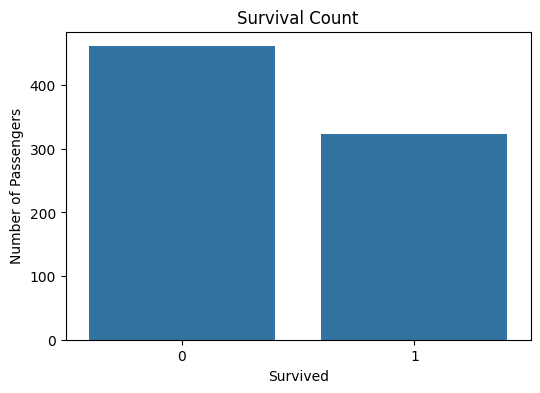

In [38]:
#survival count
plt.figure(figsize=(6,4))

sns.countplot(
    data=titanic,
    x="survived"
)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

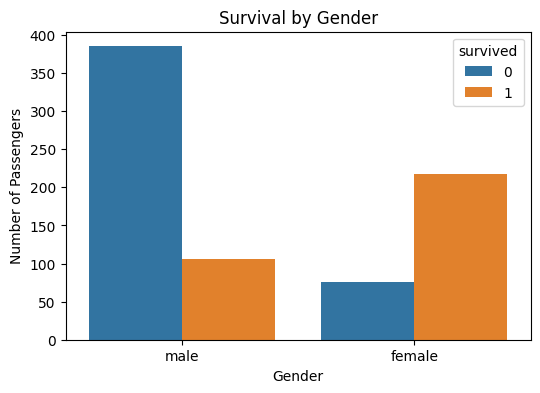

In [39]:
#survival by gender
plt.figure(figsize=(6,4))

sns.countplot(
    data=titanic,
    x="sex",
    hue="survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

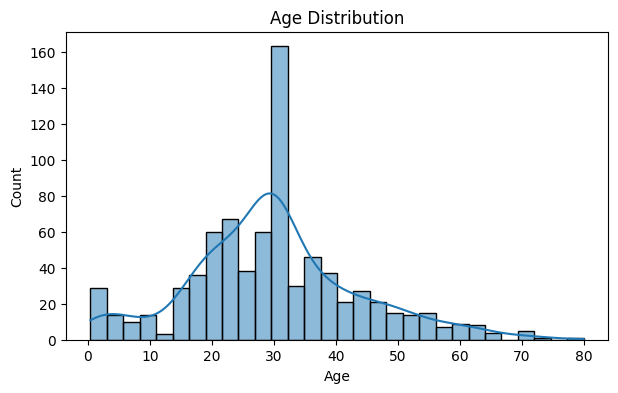

In [40]:
#age distribution histogram
plt.figure(figsize=(7,4))

sns.histplot(
    data=titanic,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

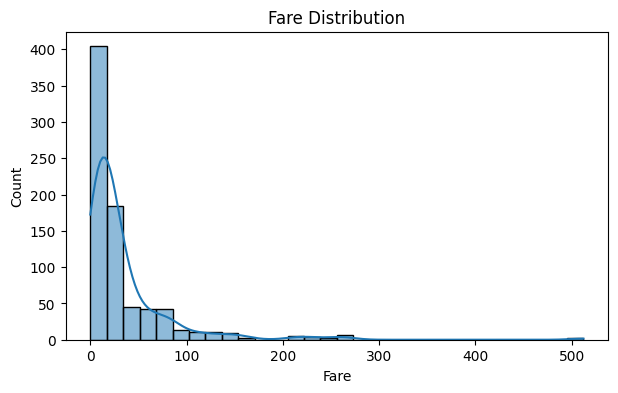

In [41]:
#fare distribution histogram
plt.figure(figsize=(7,4))

sns.histplot(
    data=titanic,
    x="fare",
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

In [42]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

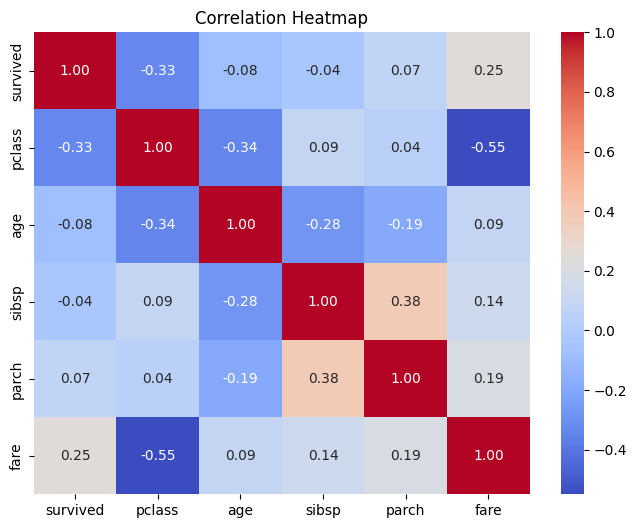

In [44]:
#heat map
plt.figure(figsize=(8,6))

sns.heatmap(
    titanic[corr_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

BUILDING AND TRAINING THE MODELS

In [63]:
X = titanic.drop(columns=["survived"])
y = titanic["survived"]
X = X.drop(columns=["alive", "class"])

In [64]:
print(X.columns.tolist())

['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'adult_male', 'embark_town', 'alone']


In [65]:
categorical_features = [
    "sex",
    "embarked",
    "who",
    "embark_town"
]
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [68]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [69]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

print(X_train_scaled.head())

(627, 14)
(157, 14)
       pclass       age     sibsp     parch      fare  adult_male     alone  \
869  0.888516 -1.853154  0.459068  0.691739 -0.472521   -1.164965 -1.164965   
37   0.888516 -0.627402 -0.519965 -0.483655 -0.539675    0.858395  0.858395   
380 -1.442444  0.886763 -0.519965 -0.483655  4.240459   -1.164965  0.858395   
825  0.888516  0.012106 -0.519965 -0.483655 -0.563633    0.858395  0.858395   
199 -0.276964 -0.411093 -0.519965 -0.483655 -0.431865   -1.164965  0.858395   

     sex_male  embarked_Q  embarked_S   who_man  who_woman  \
869  0.758536   -0.278064    0.612372 -1.164965  -0.679366   
37   0.758536   -0.278064    0.612372  0.858395  -0.679366   
380 -1.318329   -0.278064   -1.632993 -1.164965   1.471960   
825  0.758536    3.596294   -1.632993  0.858395  -0.679366   
199 -1.318329   -0.278064    0.612372 -1.164965   1.471960   

     embark_town_Queenstown  embark_town_Southampton  
869               -0.278064                 0.612372  
37                -0.2

In [72]:
#logistic regression model
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [74]:
y_pred_log = log_model.predict(X_test_scaled)
y_pred_log

array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0])

In [75]:
#evaluating model
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8662420382165605

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89        92
           1       0.83      0.85      0.84        65

    accuracy                           0.87       157
   macro avg       0.86      0.86      0.86       157
weighted avg       0.87      0.87      0.87       157


Confusion Matrix:
[[81 11]
 [10 55]]


In [76]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [77]:
y_pred_dt = dt_model.predict(X_test_scaled)

In [78]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.802547770700637

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        92
           1       0.79      0.71      0.75        65

    accuracy                           0.80       157
   macro avg       0.80      0.79      0.79       157
weighted avg       0.80      0.80      0.80       157


Confusion Matrix:
[[80 12]
 [19 46]]


In [79]:
#random forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [81]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf

array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0])

In [82]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8343949044585988

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        92
           1       0.83      0.75      0.79        65

    accuracy                           0.83       157
   macro avg       0.83      0.82      0.83       157
weighted avg       0.83      0.83      0.83       157


Confusion Matrix:
[[82 10]
 [16 49]]


In [83]:
print(y.value_counts())

survived
0    461
1    323
Name: count, dtype: int64


In [84]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.866242
1,Decision Tree,0.802548
2,Random Forest,0.834395


In [86]:
from sklearn.metrics import f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.866242,0.839695
1,Decision Tree,0.802548,0.747967
2,Random Forest,0.834395,0.790323


In [90]:
#regression model
# Select only numerical features
# 1. Select numerical features
reg_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

X_reg = df[reg_features].copy()
y_reg = df["fare"].copy()

# 2. Check missing values
print("Missing values before handling:")
print(X_reg.isnull().sum())

# 3. Fill missing age with median
X_reg["age"] = X_reg["age"].fillna(X_reg["age"].median())

# 4. Check again
print("\nMissing values after handling:")
print(X_reg.isnull().sum())

# 5. Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# 6. Standard Scaling
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# 7. Create Linear Regression model
reg_model = LinearRegression()

# 8. Train model
reg_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

# 9. Prediction
y_pred_reg = reg_model.predict(X_test_reg_scaled)

# 10. Evaluation
mae = mean_absolute_error(y_test_reg, y_pred_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg, y_pred_reg)

print("\n========== REGRESSION RESULTS ==========")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Missing values before handling:
pclass      0
age       177
sibsp       0
parch       0
dtype: int64

Missing values after handling:
pclass    0
age       0
sibsp     0
parch     0
dtype: int64

========== REGRESSION RESULTS ==========
MAE : 19.78196909043907
MSE : 946.3355043476649
RMSE: 30.762566608585587
R²  : 0.3884468201561928


SAVING THE MODELS

In [96]:
joblib.dump(reg_model, "titanic_linear_regression.pkl")

['titanic_linear_regression.pkl']

In [97]:
joblib.dump(log_model, "titanic_logistic_regression.pkl")

['titanic_logistic_regression.pkl']

In [98]:
joblib.dump(dt_model, "titanic_decision_tree.pkl")

['titanic_decision_tree.pkl']

In [99]:
joblib.dump(rf_model, "titanic_random_forest.pkl")

['titanic_random_forest.pkl']